# Reconstruct a synthetic air shower

This notebook is a truth-controlled test of the plane-front direction mathematics. We choose a known sky-arrival direction, generate the station times implied by that direction, reconstruct the direction using only station positions, times, and timing uncertainties, and compare the recovered result with the hidden truth.

## 1. Imports, units, and reproducibility

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

C_M_PER_NS = 0.299792458
RNG_SEED = 20260829

## 2. Define a synthetic detector array

In [2]:
station_coordinates_m = np.array(
    [
        [-1500.0, -1500.0, 35.0],
        [0.0, -1500.0, 22.0],
        [1500.0, -1500.0, 45.0],
        [-1500.0, 0.0, 18.0],
        [0.0, 0.0, 30.0],
        [1500.0, 0.0, 12.0],
        [-1500.0, 1500.0, 55.0],
        [0.0, 1500.0, 42.0],
        [1500.0, 1500.0, 60.0],
        [-750.0, -750.0, 28.0],
        [750.0, -750.0, 20.0],
        [-750.0, 750.0, 46.0],
        [750.0, 750.0, 38.0],
    ],
    dtype=float,
)

timing_uncertainties_ns = np.array(
    [
        8.0,
        12.0,
        10.0,
        15.0,
        7.0,
        18.0,
        11.0,
        9.0,
        14.0,
        8.0,
        16.0,
        10.0,
        13.0,
    ],
    dtype=float,
)

if station_coordinates_m.ndim != 2 or station_coordinates_m.shape[1] != 3:
    raise ValueError(
        "Station coordinates must have shape (N, 3) where N is the number of stations."
    )

if len(timing_uncertainties_ns) != len(station_coordinates_m):
    raise ValueError("Every station must have exactly one timing uncertainty.")

if not np.isfinite(station_coordinates_m).all():
    raise ValueError("Station coordinates  must be finite.")

if not np.isfinite(timing_uncertainties_ns).all():
    raise ValueError("Timing uncertainties must be finite.")

if (timing_uncertainties_ns <= 0.0).any():
    raise ValueError("Timing uncertainties must be positive.")

station_names = [f"S{number:02d}" for number in range(1, len(station_coordinates_m) + 1)]

synthetic_stations = pd.DataFrame(station_coordinates_m, columns=["x_m", "y_m", "z_m"])

synthetic_stations.insert(0, "station_name", station_names)
synthetic_stations["dt_ns"] = timing_uncertainties_ns

synthetic_stations

,station_name,x_m,y_m,z_m,dt_ns
0,S01,-1500.0,-1500.0,35.0,8.0
1,S02,0.0,-1500.0,22.0,12.0
2,S03,1500.0,-1500.0,45.0,10.0
3,S04,-1500.0,0.0,18.0,15.0
4,S05,0.0,0.0,30.0,7.0
5,S06,1500.0,0.0,12.0,18.0
6,S07,-1500.0,1500.0,55.0,11.0
7,S08,0.0,1500.0,42.0,9.0
8,S09,1500.0,1500.0,60.0,14.0
9,S10,-750.0,-750.0,28.0,8.0


## 3. Choose the hidden true shower direction

In [3]:
TRUE_ZENITH_DEG = 42.0
TRUE_AZIMUTH_DEG = 55.0
TRUE_ORIGIN_TIME_NS = 100000.0

theta_true_rad = np.deg2rad(TRUE_ZENITH_DEG)
phi_true_rad = np.deg2rad(TRUE_AZIMUTH_DEG)

sky_direction_true = np.array(
    [
        np.sin(theta_true_rad) * np.cos(phi_true_rad),
        np.sin(theta_true_rad) * np.sin(phi_true_rad),
        np.cos(theta_true_rad),
    ],
    dtype=float,
)

propagation_direction_true = -sky_direction_true

direction_norm = np.linalg.norm(sky_direction_true)

if not np.isclose(direction_norm, 1.0, rtol=0.0, atol=1e-12):
    raise ValueError(f"The true sky direction is not a unit vector. Norm = {direction_norm}")

if propagation_direction_true[2] >= 0.0:
    raise ValueError("The synthetic shower must propagate downwards.")

print(f"True sky vector:         {sky_direction_true}")
print(f"True propagation vector: {propagation_direction_true}")
print(f"Sky-vector norm:         {direction_norm:.15f}")

True sky vector:         [0.38379755 0.5481197  0.74314483]
True propagation vector: [-0.38379755 -0.5481197  -0.74314483]
Sky-vector norm:         1.000000000000000


## 4. Generate ideal station arrival times

In [4]:
POSITION_COLUMNS = ["x_m", "y_m", "z_m"]

positions_m = synthetic_stations.loc[:, POSITION_COLUMNS].to_numpy(dtype=float, copy=True)

geometric_delays_ns = positions_m @ propagation_direction_true / C_M_PER_NS

synthetic_stations["t_exact_ns"] = TRUE_ORIGIN_TIME_NS + geometric_delays_ns

synthetic_stations["t_observed_ns"] = synthetic_stations["t_exact_ns"]

synthetic_stations["relative_time_ns"] = (
    synthetic_stations["t_observed_ns"] - synthetic_stations["t_observed_ns"].min()
)

synthetic_stations.loc[
    :,
    [
        "station_name",
        "x_m",
        "y_m",
        "z_m",
        "dt_ns",
        "t_exact_ns",
        "relative_time_ns",
    ],
]

,station_name,x_m,y_m,z_m,dt_ns,t_exact_ns,relative_time_ns
0,S01,-1500.0,-1500.0,35.0,8.0,104576.051777,9387.595664
1,S02,0.0,-1500.0,22.0,12.0,102687.960782,7499.504669
2,S03,1500.0,-1500.0,45.0,10.0,100710.630672,5522.174559
3,S04,-1500.0,0.0,18.0,15.0,101875.696673,6687.240560
4,S05,0.0,0.0,30.0,7.0,99925.634071,4737.177958
5,S06,1500.0,0.0,12.0,18.0,98049.937397,2861.481284
6,S07,-1500.0,1500.0,55.0,11.0,99041.482896,3853.026783
7,S08,0.0,1500.0,42.0,9.0,97153.391901,1964.935788
8,S09,1500.0,1500.0,60.0,14.0,95188.456113,0.000000
9,S10,-750.0,-750.0,28.0,8.0,102261.997813,7073.541700


## 5. Reconstruct the propagation vector

In [5]:
times_ns = synthetic_stations["t_observed_ns"].to_numpy(dtype=float, copy=True)

dt_ns = synthetic_stations["dt_ns"].to_numpy(dtype=float, copy=True)

weights = 1.0 / dt_ns**2

position_reference_m = np.average(positions_m, axis=0, weights=weights)

time_reference_ns = np.average(times_ns, weights=weights)

delta_positions_m = positions_m - position_reference_m
delta_time_ns = times_ns - time_reference_ns

design_matrix_ns = delta_positions_m / C_M_PER_NS

sqrt_weights = np.sqrt(weights)

weighted_design_matrix = design_matrix_ns * sqrt_weights[:, np.newaxis]

weighted_time_vector = delta_time_ns * sqrt_weights

(propagation_linear, residual_sum_squares, matrix_rank, singular_values) = np.linalg.lstsq(
    weighted_design_matrix, weighted_time_vector, rcond=None
)

if matrix_rank < 3:
    raise np.linalg.LinAlgError(
        " The station geometry can't determine all three direction components."
    )

linear_norm = float(np.linalg.norm(propagation_linear))

if not np.isfinite(linear_norm) or linear_norm <= 0.0:
    raise ValueError("The linear direction estimate has an invalid norm.")

propagation_initial = propagation_linear / linear_norm

if propagation_initial[2] >= 0.0:
    raise ValueError("The initial result propagates upward; check the sign convention.")

print(f"Matrix rank:                  {matrix_rank}")
print(f"Linear propagation estimate: {propagation_linear}")
print(f"Linear-vector norm:           {linear_norm:.15f}")
print(f"Linear residual output:       {residual_sum_squares}")
print(f"Singular values:              {singular_values}")

Matrix rank:                  3
Linear propagation estimate: [-0.38379755 -0.5481197  -0.74314483]
Linear-vector norm:           1.000000000000004
Linear residual output:       [2.97443107e-24]
Singular values:              [1296.91589322 1141.51106063   11.24475085]


## 6. Convert the fitted vector into sky angles

In [6]:
def propagation_from_sky_angles(theta_rad: float, phi_rad: float) -> np.ndarray:
    sky_direction = np.array(
        [
            np.sin(theta_rad) * np.cos(phi_rad),
            np.sin(theta_rad) * np.sin(phi_rad),
            np.cos(theta_rad),
        ],
        dtype=float,
    )

    return -sky_direction


def predict_station_times_ns(
    reference_time_ns: float,
    propagation_direction: np.ndarray,
    station_positions_m: np.ndarray,
    reference_position_m: np.ndarray,
) -> np.ndarray:
    centered_positions_m = station_positions_m - reference_position_m
    geometric_delays_ns = centered_positions_m @ propagation_direction / C_M_PER_NS
    return reference_time_ns + geometric_delays_ns


def standardized_timing_residuals(
    parameters: np.ndarray,
    station_positions_m: np.ndarray,
    observed_times_ns: np.ndarray,
    fit_scales_ns: np.ndarray,
    reference_position_m: np.ndarray,
) -> np.ndarray:
    reference_time_ns, theta_rad, phi_rad = parameters
    propagation_direction = propagation_from_sky_angles(theta_rad, phi_rad)
    predicted_times_ns = predict_station_times_ns(
        reference_time_ns, propagation_direction, station_positions_m, reference_position_m
    )
    return (observed_times_ns - predicted_times_ns) / fit_scales_ns


sky_initial = -propagation_initial

theta_initial_rad = np.arccos(np.clip(sky_initial[2], -1.0, 1.0))

phi_initial_rad = np.arctan2(sky_initial[1], sky_initial[0])

initial_parameters = np.array([time_reference_ns, theta_initial_rad, phi_initial_rad], dtype=float)

fit = least_squares(
    standardized_timing_residuals,
    x0=initial_parameters,
    args=(positions_m, times_ns, dt_ns, position_reference_m),
    bounds=(np.array([-np.inf, 0.0, -np.inf]), np.array([np.inf, np.pi / 2.0, np.inf])),
    method="trf",
    x_scale="jac",
)

if not fit.success:
    raise RuntimeError(f"The constrained fit failed: {fit.message}")

(fitted_reference_time_ns, theta_fit_rad, phi_fit_unwrapped_rad) = fit.x

phi_fit_rad = phi_fit_unwrapped_rad % (2.0 * np.pi)

propagation_direction_fit = propagation_from_sky_angles(theta_fit_rad, phi_fit_rad)

sky_direction_fit = -propagation_direction_fit

## 7. Evaluate timing and angular errors

In [7]:
def angular_separation_deg(first_vector: np.ndarray, second_vector: np.ndarray) -> float:
    first_norm = float(np.linalg.norm(first_vector))
    second_norm = float(np.linalg.norm(second_vector))

    if first_norm <= 0.0 or second_norm <= 0.0:
        raise ValueError("Direction vectors must have nonzero length.")

    first_unit = first_vector / first_norm
    second_unit = second_vector / second_norm

    cosine_separation = np.clip(np.dot(first_unit, second_unit), -1.0, 1.0)

    return float(np.rad2deg(np.arccos(cosine_separation)))


predicted_times_ns = predict_station_times_ns(
    fitted_reference_time_ns, propagation_direction_fit, positions_m, position_reference_m
)

timing_residuals_ns = times_ns - predicted_times_ns
standardized_residuals = timing_residuals_ns / dt_ns

theta_fit_deg = float(np.rad2deg(theta_fit_rad))
phi_fit_deg = float(np.rad2deg(phi_fit_rad))

angular_error_deg = angular_separation_deg(sky_direction_fit, sky_direction_true)

chi_square = float(np.sum(standardized_residuals**2))

degrees_of_freedom = len(times_ns) - 3
reduced_chi_square = chi_square / degrees_of_freedom

fitted_origin_time_ns = (
    fitted_reference_time_ns - position_reference_m @ propagation_direction_fit / C_M_PER_NS
)

diagnostics = synthetic_stations.loc[:, ["station_name", "dt_ns", "t_observed_ns"]].copy()

diagnostics["t_predicted_ns"] = predicted_times_ns
diagnostics["residual_ns"] = timing_residuals_ns
diagnostics["standardized_residual"] = standardized_residuals

EXACT_DIRECTION_TOLERANCE = 1e-10
EXACT_TIME_TOLERANCE_NS = 1e-8
UNIT_NORM_TOLERANCE = 1e-12

exact_scalar_results = np.array(
    [
        theta_fit_deg,
        phi_fit_deg,
        angular_error_deg,
        fitted_origin_time_ns,
        chi_square,
        reduced_chi_square,
    ],
    dtype=float,
)

if not np.isfinite(exact_scalar_results).all():
    raise AssertionError("The exact reconstruction produced non-finite results.")

np.testing.assert_allclose(
    sky_direction_fit,
    sky_direction_true,
    rtol=0.0,
    atol=EXACT_DIRECTION_TOLERANCE,
    err_msg=(
        "The fitted sky direction does not match the true direction within the specified tolerance."
    ),
)

np.testing.assert_allclose(
    np.linalg.norm(propagation_direction_fit),
    1.0,
    rtol=0.0,
    atol=UNIT_NORM_TOLERANCE,
    err_msg="The fitted propagation vector is not a unit vector.",
)

if propagation_direction_fit[2] >= 0.0:
    raise AssertionError("The fitted propagation vector does not point downward.")

if angular_error_deg > EXACT_DIRECTION_TOLERANCE:
    raise AssertionError("The exact-data angular error exceeds the specified tolerance.")

if abs(fitted_origin_time_ns - TRUE_ORIGIN_TIME_NS) > EXACT_TIME_TOLERANCE_NS:
    raise AssertionError(
        "The fitted origin time does not match the true origin time within the specified tolerance."
    )

maximum_absolute_residual_ns = float(np.max(np.abs(timing_residuals_ns)))

if maximum_absolute_residual_ns > EXACT_TIME_TOLERANCE_NS:
    raise AssertionError("The maximum absolute timing residual exceeds the specified tolerance.")

if degrees_of_freedom <= 0:
    raise AssertionError("The fit must have positive degrees of freedom.")

print("Exact-recovery assertions passed successfully.")

print(f"True zenith:              {TRUE_ZENITH_DEG:.8f} deg")
print(f"Fitted zenith:            {theta_fit_deg:.8f} deg")
print(f"True azimuth:             {TRUE_AZIMUTH_DEG:.8f} deg")
print(f"Fitted azimuth:           {phi_fit_deg:.8f} deg")
print(f"Angular error:            {angular_error_deg:.12f} deg")
print(f"True origin time:         {TRUE_ORIGIN_TIME_NS:.8f} ns")
print(f"Fitted origin time:       {fitted_origin_time_ns:.8f} ns")
print(f"Maximum timing residual: {np.max(np.abs(timing_residuals_ns)):.12e} ns")
print(f"Chi-square:               {chi_square:.12e}")
print(f"Degrees of freedom:       {degrees_of_freedom}")
print(f"Reduced chi-square:       {reduced_chi_square:.12e}")

diagnostics

Exact-recovery assertions passed successfully.
True zenith:              42.00000000 deg
Fitted zenith:            42.00000000 deg
True azimuth:             55.00000000 deg
Fitted azimuth:           55.00000000 deg
Angular error:            0.000000000000 deg
True origin time:         100000.00000000 ns
Fitted origin time:       100000.00000000 ns
Maximum timing residual: 2.910383045673e-11 ns
Chi-square:               1.601885090418e-23
Degrees of freedom:       10
Reduced chi-square:       1.601885090418e-24


,station_name,dt_ns,t_observed_ns,t_predicted_ns,residual_ns,standardized_residual
0,S01,8.0,104576.051777,104576.051777,1.455192e-11,1.818989e-12
1,S02,12.0,102687.960782,102687.960782,0.000000e+00,0.000000e+00
2,S03,10.0,100710.630672,100710.630672,0.000000e+00,0.000000e+00
3,S04,15.0,101875.696673,101875.696673,0.000000e+00,0.000000e+00
4,S05,7.0,99925.634071,99925.634071,0.000000e+00,0.000000e+00
5,S06,18.0,98049.937397,98049.937397,-1.455192e-11,-8.084397e-13
6,S07,11.0,99041.482896,99041.482896,-1.455192e-11,-1.322901e-12
7,S08,9.0,97153.391901,97153.391901,-1.455192e-11,-1.616879e-12
8,S09,14.0,95188.456113,95188.456113,-2.910383e-11,-2.078845e-12
9,S10,8.0,102261.997813,102261.997813,0.000000e+00,0.000000e+00


## 8. Add controlled timing noise and repeat

#### 8A - Reusable constrained reconstruction


In [8]:
def fit_constrained_shower(
    station_positions_m: np.ndarray,
    observed_times_ns: np.ndarray,
    timing_uncertainties_ns: np.ndarray,
    *,
    use_timing_weights: bool,
) -> dict:

    station_positions_m = np.asarray(station_positions_m, dtype=float)

    observed_times_ns = np.asarray(observed_times_ns, dtype=float)

    timing_uncertainties_ns = np.asarray(timing_uncertainties_ns, dtype=float)

    if station_positions_m.ndim != 2 or station_positions_m.shape[1] != 3:
        raise ValueError("station_positions_m must have shape (N, 3).")

    number_of_stations = station_positions_m.shape[0]

    if number_of_stations < 4:
        raise ValueError("At least four stations required.")

    if observed_times_ns.shape != (number_of_stations,):
        raise ValueError("observed_times_ns must have shape (N,).")

    if timing_uncertainties_ns.shape != (number_of_stations,):
        raise ValueError("timing_uncertainties_ns must have shape (N,)")

    if not np.isfinite(station_positions_m).all():
        raise ValueError("Station positions must be finite.")

    if not np.isfinite(observed_times_ns).all():
        raise ValueError("Observed times must be finite.")

    if not np.isfinite(timing_uncertainties_ns).all():
        raise ValueError("Timing uncertainties must be finite.")

    if (timing_uncertainties_ns <= 0.0).any():
        raise ValueError("Timing uncertainties must be positive.")

    if use_timing_weights:
        fit_scales_ns = timing_uncertainties_ns.copy()
    else:
        fit_scales_ns = np.ones_like(timing_uncertainties_ns)

    fit_weights = 1.0 / fit_scales_ns**2

    reference_position_m = np.average(station_positions_m, axis=0, weights=fit_weights)

    reference_time_ns = np.average(observed_times_ns, weights=fit_weights)

    centered_positions_m = station_positions_m - reference_position_m

    centered_times_ns = observed_times_ns - reference_time_ns

    design_matrix_ns = centered_positions_m / C_M_PER_NS

    square_root_weights = np.sqrt(fit_weights)

    weighted_design_matrix = design_matrix_ns * square_root_weights[:, np.newaxis]

    weighted_time_vector = centered_times_ns * square_root_weights

    (linear_propagation, _, matrix_rank, singular_values) = np.linalg.lstsq(
        weighted_design_matrix, weighted_time_vector, rcond=None
    )

    if matrix_rank < 3:
        raise np.linalg.LinAlgError("Station geometry can not determine all direction components")

    linear_norm = float(np.linalg.norm(linear_propagation))

    if not np.isfinite(linear_norm) or linear_norm <= 0.0:
        raise ValueError("The linear direction estimate has an invalid norm.")

    propagation_initial = linear_propagation / linear_norm

    sky_initial = -propagation_initial

    if sky_initial[2] <= 0.0:
        raise ValueError("The linear starting direction points below the horizon.")

    theta_initial_rad = np.arccos(np.clip(sky_initial[2], -1.0, 1.0))

    phi_initial_rad = np.arctan2(sky_initial[1], sky_initial[0])

    initial_parameters = np.array(
        [reference_time_ns, theta_initial_rad, phi_initial_rad], dtype=float
    )

    optimizer_result = least_squares(
        standardized_timing_residuals,
        x0=initial_parameters,
        args=(station_positions_m, observed_times_ns, fit_scales_ns, reference_position_m),
        bounds=(np.array([-np.inf, 0.0, -np.inf]), np.array([np.inf, np.pi / 2.0, np.inf])),
        method="trf",
        x_scale="jac",
    )

    if not optimizer_result.success:
        raise RuntimeError(f"The constrained fit failed: {optimizer_result.message}")

    (fitted_reference_time_ns, theta_rad, unwrapped_phi_rad) = optimizer_result.x

    phi_rad = unwrapped_phi_rad % (2.0 * np.pi)

    propagation_direction = propagation_from_sky_angles(theta_rad, phi_rad)

    sky_direction = -propagation_direction

    predicted_times_ns = predict_station_times_ns(
        fitted_reference_time_ns, propagation_direction, station_positions_m, reference_position_m
    )

    residuals_ns = observed_times_ns - predicted_times_ns

    standardized_residuals = residuals_ns / timing_uncertainties_ns

    chi_square = float(np.sum(standardized_residuals**2))

    degrees_of_freedom = number_of_stations - 3

    fitted_origin_time_ns = (
        fitted_reference_time_ns - reference_position_m @ propagation_direction / C_M_PER_NS
    )

    return {
        "theta_deg": float(np.rad2deg(theta_rad)),
        "phi_deg": float(np.rad2deg(phi_rad)),
        "sky_direction": sky_direction,
        "propagation_direction": propagation_direction,
        "reference_position_m": reference_position_m,
        "reference_time_ns": float(fitted_reference_time_ns),
        "origin_time_ns": float(fitted_origin_time_ns),
        "predicted_times_ns": predicted_times_ns,
        "residuals_ns": residuals_ns,
        "standardized_residuals": standardized_residuals,
        "chi_square": chi_square,
        "degrees_of_freedom": degrees_of_freedom,
        "reduced_chi_square": (chi_square / degrees_of_freedom),
        "matrix_rank": matrix_rank,
        "singular_values": singular_values,
        "used_timing_weights": use_timing_weights,
    }

#### 8B - Generate and reconstruct one noisy shower

In [9]:
exact_times_ns = synthetic_stations["t_exact_ns"].to_numpy(dtype=float, copy=True)

single_event_rng = np.random.default_rng(RNG_SEED)

timing_noise_ns = single_event_rng.normal(loc=0.0, scale=dt_ns, size=dt_ns.shape)

noisy_times_ns = exact_times_ns + timing_noise_ns

noisy_stations = synthetic_stations.loc[:, ["station_name", "dt_ns", "t_exact_ns"]].copy()

noisy_stations["timing_noise_ns"] = timing_noise_ns

noisy_stations["noise_in_sigma"] = timing_noise_ns / dt_ns

noisy_stations["t_noisy_ns"] = noisy_times_ns

weighted_noisy_fit = fit_constrained_shower(
    positions_m, noisy_times_ns, dt_ns, use_timing_weights=True
)

unweighted_noisy_fit = fit_constrained_shower(
    positions_m, noisy_times_ns, dt_ns, use_timing_weights=False
)

weighted_angular_error_deg = angular_separation_deg(
    weighted_noisy_fit["sky_direction"], sky_direction_true
)

unweighted_angular_error_deg = angular_separation_deg(
    unweighted_noisy_fit["sky_direction"], sky_direction_true
)

one_event_comparison = pd.DataFrame(
    [
        {
            "method": "Weighted constrained fit",
            "zenith_deg": weighted_noisy_fit["theta_deg"],
            "azimuth_deg": weighted_noisy_fit["phi_deg"],
            "angular_error_deg": (weighted_angular_error_deg),
            "reduced_chi_square": weighted_noisy_fit["reduced_chi_square"],
        },
        {
            "method": "Unweighted constrained fit",
            "zenith_deg": unweighted_noisy_fit["theta_deg"],
            "azimuth_deg": unweighted_noisy_fit["phi_deg"],
            "angular_error_deg": unweighted_angular_error_deg,
            "reduced_chi_square": unweighted_noisy_fit["reduced_chi_square"],
        },
    ]
)

print("Generated timing errors:")
display(noisy_stations)

print("One-event reconstruction comparison:")
display(one_event_comparison)

Generated timing errors:


,station_name,dt_ns,t_exact_ns,timing_noise_ns,noise_in_sigma,t_noisy_ns
0,S01,8.0,104576.051777,4.580717,0.572590,104580.632494
1,S02,12.0,102687.960782,-4.106128,-0.342177,102683.854654
2,S03,10.0,100710.630672,6.520464,0.652046,100717.151136
3,S04,15.0,101875.696673,-1.186906,-0.079127,101874.509767
4,S05,7.0,99925.634071,-6.358744,-0.908392,99919.275326
5,S06,18.0,98049.937397,7.915086,0.439727,98057.852484
6,S07,11.0,99041.482896,11.727907,1.066173,99053.210803
7,S08,9.0,97153.391901,2.295673,0.255075,97155.687575
8,S09,14.0,95188.456113,5.238357,0.374168,95193.694470
9,S10,8.0,102261.997813,-0.559173,-0.069897,102261.438641


One-event reconstruction comparison:


,method,zenith_deg,azimuth_deg,angular_error_deg,reduced_chi_square
0,Weighted constrained fit,42.006326,55.005818,0.007428,0.492757
1,Unweighted constrained fit,41.991433,55.024910,0.018740,0.518508


#### 8C - Perform 10,000 paired trials

In [10]:
NUMBER_OF_TRIALS = 10000

monte_carlo_rng = np.random.default_rng(RNG_SEED + 1)

weighted_errors_deg = np.empty(NUMBER_OF_TRIALS, dtype=float)

unweighted_errors_deg = np.empty(NUMBER_OF_TRIALS, dtype=float)

weighted_reduced_chi_square = np.empty(NUMBER_OF_TRIALS, dtype=float)

unweighted_reduced_chi_square = np.empty(NUMBER_OF_TRIALS, dtype=float)

for trial_index in range(NUMBER_OF_TRIALS):
    trial_noise_ns = monte_carlo_rng.normal(loc=0.0, scale=dt_ns, size=dt_ns.shape)

    trial_times_ns = exact_times_ns + trial_noise_ns

    weighted_result = fit_constrained_shower(
        positions_m, trial_times_ns, dt_ns, use_timing_weights=True
    )

    unweighted_result = fit_constrained_shower(
        positions_m, trial_times_ns, dt_ns, use_timing_weights=False
    )

    weighted_errors_deg[trial_index] = angular_separation_deg(
        weighted_result["sky_direction"], sky_direction_true
    )

    unweighted_errors_deg[trial_index] = angular_separation_deg(
        unweighted_result["sky_direction"], sky_direction_true
    )

    weighted_reduced_chi_square[trial_index] = weighted_result["reduced_chi_square"]

    unweighted_reduced_chi_square[trial_index] = unweighted_result["reduced_chi_square"]

expected_monte_carlo_shape = (NUMBER_OF_TRIALS,)

monte_carlo_outputs = {
    "weighted angular errors": weighted_errors_deg,
    "unweighted angular errors": unweighted_errors_deg,
    "weighted reduced chi-square": weighted_reduced_chi_square,
    "unweighted reduced chi-square": unweighted_reduced_chi_square,
}

for output_name, output_values in monte_carlo_outputs.items():
    if output_values.shape != expected_monte_carlo_shape:
        raise AssertionError(
            f"The Monte Carlo output '{output_name}' has an unexpected "
            f"shape: {output_values.shape}. Expected shape: "
            f"{expected_monte_carlo_shape}"
        )

    if not np.isfinite(output_values).all():
        raise AssertionError(
            f"The Monte Carlo output '{output_name}' contains NaN or infinite values."
        )

    if (output_values < 0.0).any():
        raise AssertionError(f"The Monte Carlo output '{output_name}' contains negative values.")

weighted_mean_reduced_chi_square = float(np.mean(weighted_reduced_chi_square))

if not 0.9 <= weighted_mean_reduced_chi_square <= 1.1:
    raise AssertionError(
        "The weighted mean reduced chi-square is unexpectedly far from "
        "one under the controlled Gaussian-noise model: "
        f"{weighted_mean_reduced_chi_square:.6f}"
    )

print(f"Monte Carlo checks passed for {NUMBER_OF_TRIALS} paired trials.")


def summarize_trials(
    method_name: str, angular_errors_deg: np.ndarray, reduced_chi_square_values: np.ndarray
) -> dict:
    return {
        "method": method_name,
        "median_error_deg": float(np.median(angular_errors_deg)),
        "p68_containment_deg": float(np.percentile(angular_errors_deg, 68.0)),
        "p95_containment_deg": float(np.percentile(angular_errors_deg, 95.0)),
        "mean_reduced_chi_square": float(np.mean(reduced_chi_square_values)),
    }


monte_carlo_summary = pd.DataFrame(
    [
        summarize_trials(
            "Weighted constrained fit", weighted_errors_deg, weighted_reduced_chi_square
        ),
        summarize_trials(
            "Unweighted constrained fit", unweighted_errors_deg, unweighted_reduced_chi_square
        ),
    ]
)

weighted_win_fraction = float(np.mean(weighted_errors_deg < unweighted_errors_deg))

paired_improvements_deg = unweighted_errors_deg - weighted_errors_deg

median_paired_improvement_deg = float(np.median(paired_improvements_deg))

display(monte_carlo_summary)

print(f"Weighted win fraction: {weighted_win_fraction:.3f}")

print(f"Median paired angular improvement: {median_paired_improvement_deg:.6f}")

Monte Carlo checks passed for 10000 paired trials.


,method,median_error_deg,p68_containment_deg,p95_containment_deg,mean_reduced_chi_square
0,Weighted constrained fit,0.064819,0.083613,0.138805,0.998752
1,Unweighted constrained fit,0.071691,0.092005,0.154051,1.070555


Weighted win fraction: 0.603
Median paired angular improvement: 0.006139


#### 8D - Plot the angular-error distributions

Weighted median:   0.064819 deg
Unweighted median: 0.071691 deg


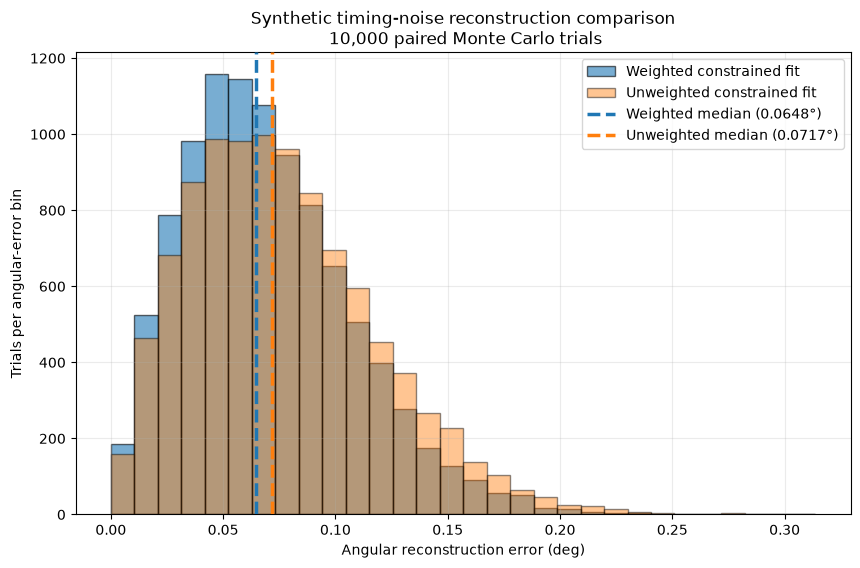

Weighted errors stored:   10,000
Unweighted errors stored: 10,000


In [11]:
maximum_error_deg = max(float(np.max(weighted_errors_deg)), float(np.max(unweighted_errors_deg)))

histogram_bins = np.linspace(0.0, maximum_error_deg, 31)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    weighted_errors_deg,
    bins=histogram_bins,
    alpha=0.60,
    color="tab:blue",
    edgecolor="black",
    label="Weighted constrained fit",
)

ax.hist(
    unweighted_errors_deg,
    bins=histogram_bins,
    alpha=0.45,
    color="tab:orange",
    edgecolor="black",
    label="Unweighted constrained fit",
)

weighted_median_error_deg = float(np.median(weighted_errors_deg))

unweighted_median_error_deg = float(np.median(unweighted_errors_deg))

print(f"Weighted median:   {weighted_median_error_deg:.6f} deg")

print(f"Unweighted median: {unweighted_median_error_deg:.6f} deg")

ax.axvline(
    weighted_median_error_deg,
    color="tab:blue",
    linestyle="--",
    linewidth=2.5,
    label=(f"Weighted median ({weighted_median_error_deg:.4f}°)"),
    zorder=10,
)

ax.axvline(
    unweighted_median_error_deg,
    color="tab:orange",
    linestyle="--",
    linewidth=2.5,
    label=(f"Unweighted median ({unweighted_median_error_deg:.4f}°)"),
    zorder=11,
)

ax.set_xlabel("Angular reconstruction error (deg)")
ax.set_ylabel("Trials per angular-error bin")
ax.set_title(
    "Synthetic timing-noise reconstruction comparison\n"
    f"{NUMBER_OF_TRIALS:,} paired Monte Carlo trials"
)

ax.grid(alpha=0.25)

ax.legend()

plt.show()

print(f"Weighted errors stored:   {len(weighted_errors_deg):,}")
print(f"Unweighted errors stored: {len(unweighted_errors_deg):,}")

## 9. Scientific conclusions and implementation requirements

### 9.1 Purpose of this validation

This notebook tested whether the plane-front timing model can recover a known cosmic-ray sky-arrival direction from synthetic station positions, arrival times, and timing uncertainties.

The reconstruction received only:

- station positions;
- observed station times;
- timing uncertainties.

The known direction was used to generate the synthetic measurements and evaluate the reconstruction, but it was not passed into the fitting function.

### 9.2 Exact-data recovery

For 13 synthetic stations, the hidden truth was

$$
\theta_{\mathrm{true}}=42^\circ,
\qquad
\phi_{\mathrm{true}}=55^\circ,
\qquad
t_{0,\mathrm{true}}=100000\ \mathrm{ns}.
$$

With no timing noise, the constrained reconstruction recovered the direction and origin time to floating-point precision:

| Quantity | Result |
|---|---:|
| Angular separation | $0.000000000000^\circ$ |
| Maximum absolute timing residual | $2.91\times10^{-11}\ \mathrm{ns}$ |
| Reduced $\chi^2$ | $1.60\times10^{-24}$ |

The exact-recovery assertions also verified that the returned values were finite, the reconstructed direction was a unit vector, the propagation vector pointed downward, the origin time agreed with the hidden truth, the timing residuals remained below the specified tolerance, and the fit had positive degrees of freedom.

The extremely small nonzero residuals are numerical round-off rather than physical measurement errors. This result verifies that the timing sign, weighted centring, direction parameterization, unit-vector constraint, and conversion from propagation direction to sky-arrival direction are mutually consistent for this synthetic configuration.

### 9.3 One noisy realization

Independent Gaussian timing noise was generated according to

$$
\epsilon_i\sim\mathcal N(0,dt_i^2),
\qquad
t_i^{\mathrm{observed}}=t_i^{\mathrm{exact}}+\epsilon_i.
$$

The same noisy event was reconstructed with and without timing-uncertainty weights:

| Method | Zenith | Azimuth | Angular error | Reduced $\chi^2$ |
|---|---:|---:|---:|---:|
| Weighted constrained fit | $42.006326^\circ$ | $55.005818^\circ$ | $0.007428^\circ$ | 0.492757 |
| Unweighted constrained fit | $41.991433^\circ$ | $55.024910^\circ$ | $0.018740^\circ$ | 0.518508 |

The weighted reconstruction was more accurate for this realization. One random event, however, cannot establish general superiority, which motivated the paired Monte Carlo experiment.

### 9.4 Paired Monte Carlo experiment

The comparison was repeated for 10,000 independent timing-noise realizations. During every trial, the weighted and unweighted methods received exactly the same noisy station times. This pairing isolates the effect of the fitting method from random differences between simulated events.

| Method | Median error | 68% containment | 95% containment | Mean reduced $\chi^2$ |
|---|---:|---:|---:|---:|
| Weighted constrained fit | $0.064819^\circ$ | $0.083613^\circ$ | $0.138805^\circ$ | 0.998752 |
| Unweighted constrained fit | $0.071691^\circ$ | $0.092005^\circ$ | $0.154051^\circ$ | 1.070555 |

The weighted reconstruction:

- produced the smaller angular error in 60.3% of paired trials;
- achieved a median paired improvement of $0.006139^\circ$;
- reduced the median angular error by approximately 9.6%;
- improved both the 68% and 95% containment angles.

All four Monte Carlo result arrays passed automated shape, finite-value, and non-negativity checks. The mean reduced $\chi^2$ for the weighted reconstruction was 0.998752, which is consistent with one under the controlled assumptions that the plane-front model is correct, timing errors are independent and Gaussian, and each supplied `dt` equals the true standard deviation of that station's timing error.

For the unweighted reconstruction, the reported $\chi^2$ is a common post-fit diagnostic calculated using the physical `dt` values. It is not the objective minimized by the unweighted optimizer, so its mean reduced $\chi^2$ should not be interpreted in exactly the same way as that of the weighted fit.

### 9.5 Verified Auger direction convention

The [Auger tutorial audit](../docs/auger_tutorial_audit.md) established the local convention used by the released data:

- $+x$: approximately east;
- $+y$: approximately north;
- $+z$: upward;
- $\theta$: zenith angle measured from $+z$;
- $\phi$: sky-arrival azimuth measured counterclockwise from $+x$ toward $+y$;
- $\mathbf a$: unit vector pointing toward the arrival direction in the sky;
- $\mathbf u=-\mathbf a$: downward shower-propagation vector.

Therefore,

$$
\mathbf a=
\left(
\sin\theta\cos\phi,
\sin\theta\sin\phi,
\cos\theta
\right),
\qquad
\mathbf u=-\mathbf a.
$$

The notebook uses this verified Auger local convention. No additional $90^\circ$ or $180^\circ$ azimuth correction is required.

### 9.6 Scientific conclusion

For the fixed detector geometry and true direction studied here, and under independent Gaussian timing noise with known station-specific standard deviations, timing-uncertainty-weighted constrained least squares produced a modest but repeatable improvement over the unweighted constrained fit.

The appropriate conclusion is therefore:

> The synthetic experiment validates the internal plane-front reconstruction mathematics and supports timing-uncertainty weighting as the primary baseline under the stated noise model.

This notebook does **not** demonstrate the angular resolution of the Pierre Auger Observatory, improvement over Auger's official reconstruction, or superiority of weighting for every detector geometry and noise process. The unusually small errors are expected because the data were generated from the same ideal plane-front model being fitted and contain only controlled timing noise.

### 9.7 Limitations of the present experiment

This experiment holds fixed:

- one station geometry and multiplicity;
- one zenith and azimuth;
- one pattern of timing uncertainties;
- an exactly planar shower front;
- independent Gaussian timing errors;
- correctly calibrated `dt` values.

It does not yet study:

- all azimuth quadrants, nearly vertical showers, or high-zenith showers;
- planar, weak, ill-conditioned, or degenerate station geometries;
- timing outliers, correlated errors, or uncertainty miscalibration;
- rejected triggers, saturation, missing stations, or other detector-quality failures;
- shower-front curvature;
- bias, coverage, or performance on real Auger events.

The notebook-local linear initializer requires three-dimensional numerical rank, even though a surface array can be planar or nearly planar. The production fitter corrects this limitation by supporting rank-two surface geometry and using the unit-vector constraint to recover the downward vertical component.

### 9.8 Production extraction status

The verified mathematics has now been extracted into `src/auger_reco/physics/plane_front.py`. Its automated tests cover the production requirements identified by this notebook, including:

- typed success results and structured failure diagnostics;
- physical and objective residuals kept distinct;
- finite-value, shape, uncertainty, geometry-rank, and conditioning checks;
- planar-array support and multiple physically valid optimizer seeds;
- stable unit-vector and angular-separation calculations;
- exact, noisy, quadrant, near-vertical, high-zenith, invalid-input, and degenerate-geometry tests.

The notebook remains an explanatory experiment rather than the authoritative implementation. Real-event artifact saving, batch provenance, and evaluation-target quarantine are integration requirements for the next stage.

### 9.9 Decision and next stage

The timing-uncertainty-weighted constrained plane-front fit becomes the primary physics baseline. The unweighted constrained fit remains a required comparator.

The truth-controlled synthetic validation and production extraction are complete for their stated purposes. The next stage is to finish the typed Auger JSON adapter, run the production fitter on event `081847956000` as an unblinded integration and convention check, predeclare a different event for a reference-hidden demonstration, and then advance through a varied 10--20-event smoke test to the fixed pilot cohort.
